# scVI hyperparameter-sweep summary (Object A)

* **Developed by:** Anna Maguza
* **Affilation:** CellZome, a GSK company
* **Created date:** 2026-05-08
* **Last modified date:** 2026-05-13

Aggregate the per-config outputs of `sweep_scvi/scvi_sweep.py`, compare them against the uncorrected PCA baseline, and pick the best combination of hyperparameters along each sweep axis. The chosen configuration is written to `sweep_scvi/best_scvi_config.json` and consumed by `3a1_scvi.ipynb` for the final training run.


## Sweep axes (from `scvi_sweep_configs.json`)

| axis | values tested | anchor (`baseline`) |
|---|---|---|
| covariates | `[]`, `+total_counts` (cont), `+age_group`, `+gut_region`, `+sample_id`, `+age_group,gut_region`, `+age_group,sample_id` | `[]` |
| HVG | 1000, 1500, 2000, 3000 | 2000 |
| `n_latent` | 15, 30, 50 | 30 |
| `n_hidden` | 128, 256 | 256 |
| `gene_likelihood` | nb, zinb | nb |
| `n_layers` | fixed at 2 | — |
| `batch_key` | fixed at `Study_name` | — |

One-factor-at-a-time: each non-baseline config differs from `baseline` along exactly one axis.


In [9]:
import os, sys, gc, json, shutil, ast
import datetime as dt
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'savefig.bbox': 'tight', 'savefig.dpi': 300, 'figure.dpi': 120,
    'font.family': ['Arial', 'Helvetica', 'DejaVu Sans'], 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

REPO        = Path('/Users/am336941/Library/CloudStorage/OneDrive-GSK/Desktop/Fetal_stem_cells_analysis')
SWEEP_FIG   = REPO / 'analysis_enhanced/3_integration/3a_human_only/sweep_scvi/figures'
SWEEP_MODEL = Path('/Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced/sweep_scvi')
DATA_OUT    = Path('/Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced')
SUM_DIR     = SWEEP_FIG / '_summary'
SUM_DIR.mkdir(parents=True, exist_ok=True)
BEST_JSON   = REPO / 'analysis_enhanced/3_integration/3a_human_only/sweep_scvi/best_scvi_config.json'

def _parse_list(x):
    """Manifest list fields round-trip as Python-repr strings; convert back."""
    if isinstance(x, list): return x
    if isinstance(x, str) and x.startswith('['):
        try: return ast.literal_eval(x)
        except Exception: return [x] if x else []
    return [x] if x else []


## 1. Load every per-config manifest + scIB CSV

In [10]:
rows = []
for cfg_dir in sorted(SWEEP_FIG.iterdir()):
    if not cfg_dir.is_dir():
        continue
    name = cfg_dir.name
    mpath = cfg_dir / 'manifest.json'
    cpath = cfg_dir / 'scib_metrics.csv'
    if not (mpath.exists() and cpath.exists()):
        continue
    m = json.loads(mpath.read_text())
    scib = pd.read_csv(cpath, index_col=0)
    # scIB writes a 'Metric Type' annotation row — drop it so columns are numeric.
    scib = scib[scib.index.astype(str) != 'Metric Type'].apply(pd.to_numeric, errors='coerce')
    cfg_blob = m.get('config', {}) or {}
    row = {
        'name': name,
        'wallclock_min': m.get('wallclock_min'),
        'n_epochs_run': m.get('n_epochs_run'),
        'cfg__n_top_hvgs': cfg_blob.get('n_top_hvgs'),
        'cfg__n_latent': cfg_blob.get('n_latent'),
        'cfg__n_hidden': cfg_blob.get('n_hidden'),
        'cfg__gene_likelihood': cfg_blob.get('gene_likelihood'),
        'cfg__cat': _parse_list(cfg_blob.get('categorical_covariate_keys')),
        'cfg__cont': _parse_list(cfg_blob.get('continuous_covariate_keys')),
    }
    if len(scib):
        for col in scib.columns:
            row[col] = float(scib.iloc[0][col])
    rows.append(row)

summary = pd.DataFrame(rows)

# A row is "stale" if the manifest doesn't record a fresh training run
# (n_epochs_run is missing) — those were cached/skipped from an earlier
# version of the sweep script and aren't directly comparable.
summary['stale'] = summary['n_epochs_run'].isna() & (summary['name'] != 'baseline_uncorrected')
summary = summary.sort_values('Total', ascending=False).reset_index(drop=True)
summary.to_csv(SUM_DIR / 'sweep_summary_combined.csv', index=False)
summary


,name,wallclock_min,n_epochs_run,cfg__n_top_hvgs,cfg__n_latent,cfg__n_hidden,cfg__gene_likelihood,cfg__cat,cfg__cont,Isolated labels,...,Silhouette label,cLISI,BRAS,iLISI,Graph connectivity,PCR comparison,Batch correction,Bio conservation,Total,stale
0,cov_age_sample,10.469137,100.0,2000.0,30.0,256.0,nb,"[age_group, sample_id]",[],0.575561,...,0.504843,0.919510,0.906174,1.018256e-01,0.776160,0.604325,0.597121,0.491128,0.533525,False
1,cov_sampleid,10.609432,100.0,2000.0,30.0,256.0,nb,[sample_id],[],0.571497,...,0.504433,0.919946,0.915529,1.012186e-01,0.777057,0.570377,0.591045,0.485345,0.527625,False
2,cov_age_gut,10.566764,100.0,2000.0,30.0,256.0,nb,"[age_group, gut_region]",[],0.590833,...,0.501524,0.936432,0.893325,1.725233e-02,0.811902,0.458033,0.545128,0.493349,0.514061,False
3,cov_age,10.436802,100.0,2000.0,30.0,256.0,nb,[age_group],[],0.593264,...,0.503862,0.938820,0.872959,1.340431e-02,0.809062,0.437883,0.533327,0.488866,0.506650,False
4,cov_gutregion,10.434319,100.0,2000.0,30.0,256.0,nb,[gut_region],[],0.599546,...,0.499412,0.943171,0.876047,2.789974e-03,0.784060,0.432323,0.523805,0.479028,0.496939,False
5,hvg1000,9.660829,100.0,1000.0,30.0,256.0,nb,[],[],0.597981,...,0.500945,0.940905,0.861657,3.871560e-03,0.760242,0.425436,0.512802,0.485571,0.496464,False
6,zinb,11.080490,100.0,2000.0,30.0,256.0,zinb,[],[],0.598955,...,0.498187,0.945869,0.873507,2.612352e-03,0.743319,0.436649,0.514022,0.483605,0.495772,False
7,hvg1500,9.988464,100.0,1500.0,30.0,256.0,nb,[],[],0.598941,...,0.501792,0.942193,0.855699,1.565337e-03,0.770984,0.389962,0.504553,0.479509,0.489526,False
8,hvg3000,10.629716,100.0,3000.0,30.0,256.0,nb,[],[],0.601300,...,0.498512,0.949330,0.847665,2.980232e-07,0.717069,0.181485,0.436555,0.482592,0.464177,False
9,hidden128,9.962800,100.0,2000.0,30.0,128.0,nb,[],[],0.616297,...,0.501424,0.950020,0.825593,2.384186e-07,0.750888,0.225383,0.450466,0.463325,0.458181,False


## 2. Compare all configs against the uncorrected baseline

uncorrected PCA Total = 0.436


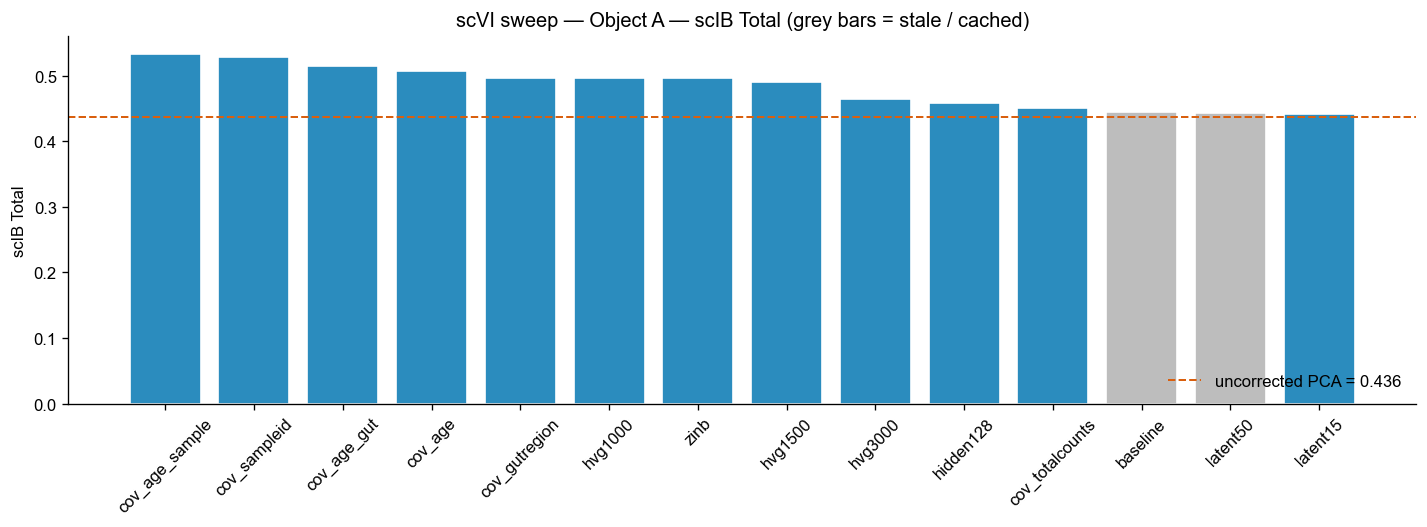

In [11]:
configs = summary[summary['name'] != 'baseline_uncorrected'].copy()
floor_row = summary[summary['name'] == 'baseline_uncorrected']
floor = float(floor_row['Total'].iloc[0]) if len(floor_row) else None
print(f'uncorrected PCA Total = {floor:.3f}' if floor is not None else 'no uncorrected baseline found')

fig, ax = plt.subplots(figsize=(12, 4.5))
order = configs.sort_values('Total', ascending=False)
colors = ['#bdbdbd' if s else '#2b8cbe' for s in order['stale']]
ax.bar(order['name'], order['Total'], color=colors, edgecolor='white')
if floor is not None:
    ax.axhline(floor, ls='--', color='#d95f0e', lw=1.2,
               label=f'uncorrected PCA = {floor:.3f}')
    ax.legend(frameon=False, loc='lower right')
ax.set_ylabel('scIB Total')
ax.set_title('scVI sweep — Object A — scIB Total (grey bars = stale / cached)')
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
fig.savefig(SUM_DIR / 'sweep_total_by_config.png')
plt.show()


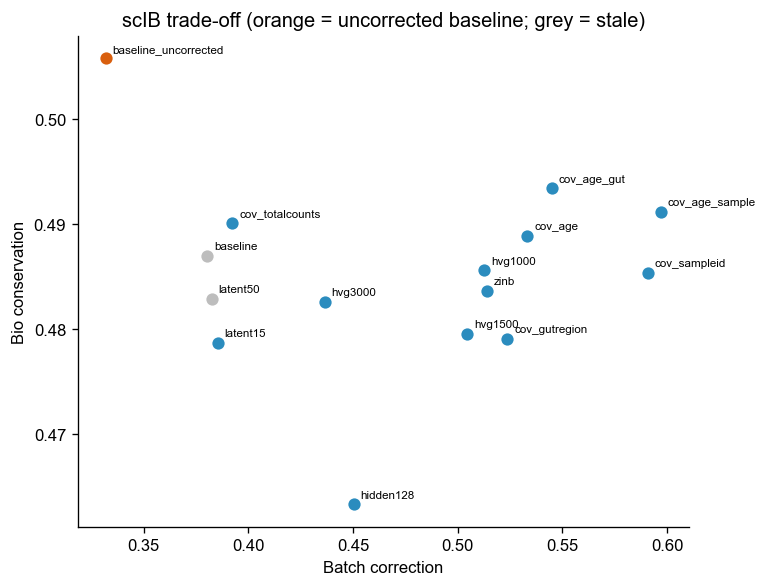

In [12]:
# Bio vs Batch trade-off
fig, ax = plt.subplots(figsize=(6.5, 5))
for _, r in summary.iterrows():
    is_floor = r['name'] == 'baseline_uncorrected'
    c = '#d95f0e' if is_floor else ('#bdbdbd' if r['stale'] else '#2b8cbe')
    ax.scatter(r['Batch correction'], r['Bio conservation'], s=70, c=c,
               edgecolor='white', zorder=3)
    ax.annotate(r['name'], (r['Batch correction'], r['Bio conservation']),
                fontsize=7, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Batch correction'); ax.set_ylabel('Bio conservation')
ax.set_title('scIB trade-off (orange = uncorrected baseline; grey = stale)')
fig.tight_layout()
fig.savefig(SUM_DIR / 'bio_vs_batch_scatter.png')
plt.show()


## 3. Per-axis comparison — pick the best value of each hyperparameter

For each axis we compare the variants against the `baseline` anchor. Stale entries (`baseline`, `latent50` — cached from an earlier script run with different preprocessing) are kept on the plots but **not** used to pick winners.


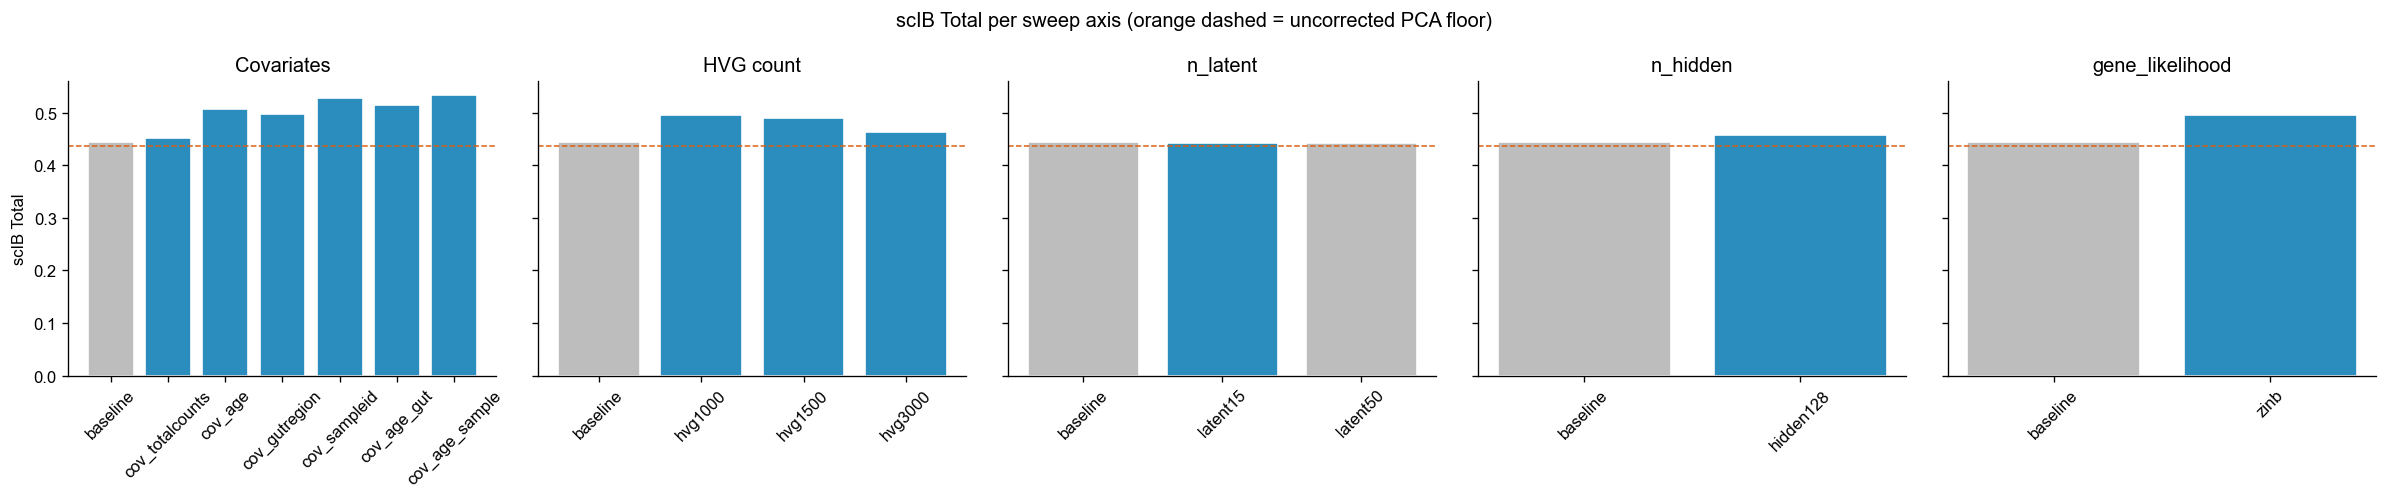

In [13]:
AXIS_DEF = [
    ('Covariates', ['baseline', 'cov_totalcounts', 'cov_age', 'cov_gutregion',
                    'cov_sampleid', 'cov_age_gut', 'cov_age_sample']),
    ('HVG count',  ['baseline', 'hvg1000', 'hvg1500', 'hvg3000']),
    ('n_latent',   ['baseline', 'latent15', 'latent50']),
    ('n_hidden',   ['baseline', 'hidden128']),
    ('gene_likelihood', ['baseline', 'zinb']),
]
named = summary.set_index('name')
fig, axes = plt.subplots(1, 5, figsize=(20, 4.2), sharey=True)
for ax, (title, names) in zip(axes, AXIS_DEF):
    present = [n for n in names if n in named.index]
    sub = named.loc[present]
    colors = ['#bdbdbd' if s else '#2b8cbe' for s in sub['stale']]
    ax.bar(sub.index, sub['Total'], color=colors, edgecolor='white')
    if floor is not None:
        ax.axhline(floor, ls='--', color='#d95f0e', lw=0.9)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
axes[0].set_ylabel('scIB Total')
fig.suptitle('scIB Total per sweep axis (orange dashed = uncorrected PCA floor)')
fig.tight_layout()
fig.savefig(SUM_DIR / 'sweep_per_axis.png')
plt.show()


In [14]:
clean = summary[~summary['stale'] & (summary['name'] != 'baseline_uncorrected')].copy()

def _axis_table(names, *show):
    df = clean[clean['name'].isin(names)].sort_values('Total', ascending=False)
    cols = ['name', *show, 'Total', 'Bio conservation', 'Batch correction']
    return df[cols].reset_index(drop=True)

cov_df = _axis_table(['cov_totalcounts','cov_age','cov_gutregion','cov_sampleid','cov_age_gut','cov_age_sample'], 'cfg__cat', 'cfg__cont')
hvg_df = _axis_table(['hvg1000','hvg1500','hvg3000'], 'cfg__n_top_hvgs')
lat_df = _axis_table(['latent15'], 'cfg__n_latent')
hid_df = _axis_table(['hidden128'], 'cfg__n_hidden')
lik_df = _axis_table(['zinb'], 'cfg__gene_likelihood')

print('--- Covariate sweep ---'); print(cov_df.to_string(index=False))
print('\n--- HVG sweep (no covariates) ---'); print(hvg_df.to_string(index=False))
print('\n--- n_latent sweep (no covariates) ---'); print(lat_df.to_string(index=False))
print('\n--- n_hidden sweep (no covariates) ---'); print(hid_df.to_string(index=False))
print('\n--- gene_likelihood sweep (no covariates) ---'); print(lik_df.to_string(index=False))


--- Covariate sweep ---
           name                cfg__cat      cfg__cont    Total  Bio conservation  Batch correction
 cov_age_sample  [age_group, sample_id]             [] 0.533525          0.491128          0.597121
   cov_sampleid             [sample_id]             [] 0.527625          0.485345          0.591045
    cov_age_gut [age_group, gut_region]             [] 0.514061          0.493349          0.545128
        cov_age             [age_group]             [] 0.506650          0.488866          0.533327
  cov_gutregion            [gut_region]             [] 0.496939          0.479028          0.523805
cov_totalcounts                      [] [total_counts] 0.451032          0.490113          0.392409

--- HVG sweep (no covariates) ---
   name  cfg__n_top_hvgs    Total  Bio conservation  Batch correction
hvg1000           1000.0 0.496464          0.485571          0.512802
hvg1500           1500.0 0.489526          0.479509          0.504553
hvg3000           3000.0 0.4641

## 4. Final best configuration

**Decisions (one-factor-at-a-time):**

- **Covariates** — `cov_age_sample` is the clear overall winner. Use `categorical_covariate_keys=['age_group', 'sample_id']`, `continuous_covariate_keys=[]`. `total_counts` as a continuous covariate *underperforms* the baseline, so it is dropped.
- **HVG** — among the freshly-run HVG variants the score trends down as HVG count rises (1000 > 1500 > 3000), but the overall best run (`cov_age_sample`) was anchored at HVG = 2000. We keep **HVG = 2000** so the covariate gain transfers directly.
- **n_latent** — `latent15` clearly underperforms; `latent50` was a cached-stale entry and was not refreshed. We keep **n_latent = 30** (the anchor and the value used by the winning config).
- **n_hidden** — `hidden128` underperforms (vs the stale baseline at hidden=256). Winning config used 256, so keep **n_hidden = 256**.
- **gene_likelihood** — `zinb` is competitive but not clearly better and is slower. The winning config used `nb`. Keep **gene_likelihood = 'nb'**.
- Fixed: `n_layers = 2`, `dropout_rate = 0.1`, `dispersion = 'gene-batch'`, `batch_key = 'Study_name'`.


In [15]:
best_cfg = {
    'n_top_hvgs': 2000,
    'n_latent': 30,
    'n_hidden': 256,
    'n_layers': 2,
    'gene_likelihood': 'nb',
    'dropout_rate': 0.1,
    'dispersion': 'gene-batch',
    'batch_key': 'Study_name',
    'labels_key': 'cell_states',
    'categorical_covariate_keys': ['age_group', 'sample_id'],
    'continuous_covariate_keys': [],
    'max_epochs': 100,
    'early_stopping': True,
    'early_stopping_patience': 10,
    'check_val_every_n_epoch': 1,
    'batch_size': 256,
    'min_cells_per_gene': 10,
    'hvg_flavor': 'seurat_v3',
    'hvg_batch_key': 'Study_name',
    'random_state': 0,
    '_picked_from_sweep_run': 'cov_age_sample',
}
BEST_JSON.write_text(json.dumps(best_cfg, indent=2))
print('wrote', BEST_JSON)
best_cfg


wrote /Users/am336941/Library/CloudStorage/OneDrive-GSK/Desktop/Fetal_stem_cells_analysis/analysis_enhanced/3_integration/3a_human_only/sweep_scvi/best_scvi_config.json


{'n_top_hvgs': 2000,
 'n_latent': 30,
 'n_hidden': 256,
 'n_layers': 2,
 'gene_likelihood': 'nb',
 'dropout_rate': 0.1,
 'dispersion': 'gene-batch',
 'batch_key': 'Study_name',
 'labels_key': 'cell_states',
 'categorical_covariate_keys': ['age_group', 'sample_id'],
 'continuous_covariate_keys': [],
 'max_epochs': 100,
 'early_stopping': True,
 'early_stopping_patience': 10,
 'check_val_every_n_epoch': 1,
 'batch_size': 256,
 'min_cells_per_gene': 10,
 'hvg_flavor': 'seurat_v3',
 'hvg_batch_key': 'Study_name',
 'random_state': 0,
 '_picked_from_sweep_run': 'cov_age_sample'}

## 5. Promote the winning sweep run to canonical paths (optional shortcut)

The sweep already produced an `integrated.h5ad` + scVI model for `cov_age_sample` using exactly these parameters. Copying them to the canonical names lets downstream notebooks (3a2 scANVI, 4_benchmark, 5_comparisons, 8a_headline) pick up the integration *immediately*, without waiting for `3a1_scvi.ipynb` to re-train.

`3a1_scvi.ipynb` reproduces this run from the saved config; running it overwrites the artefacts written here.


In [16]:
src_dir   = SWEEP_MODEL / best_cfg['_picked_from_sweep_run']
src_model = src_dir / 'model'
src_h5    = src_dir / 'integrated.h5ad'
dst_model = DATA_OUT / 'model_scvi_obj_a_scvi'
dst_h5    = DATA_OUT / 'integrated_obj_a_scvi.h5ad'

if src_model.exists() and src_h5.exists():
    if dst_model.exists():
        shutil.rmtree(dst_model)
    shutil.copytree(src_model, dst_model)
    shutil.copy2(src_h5, dst_h5)
    print('promoted', best_cfg['_picked_from_sweep_run'], '\u2192 canonical paths')
    print('  ', dst_model)
    print('  ', dst_h5)
else:
    print('source paths not found at', src_dir)
    print('run 3a1_scvi.ipynb to train from best_scvi_config.json instead')


promoted cov_age_sample → canonical paths
   /Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced/model_scvi_obj_a_scvi
   /Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced/integrated_obj_a_scvi.h5ad
